In [0]:
%load_ext autoreload
%autoreload 2

In [0]:
%pip install -q -U -r requirements.txt
%pip install uv --quiet

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
from dotenv import load_dotenv
load_dotenv()

True

In [0]:
dbutils.library.restartPython()

In [0]:
import asyncio
import functools
import os
import uuid
from datetime import datetime
from typing import Any, Dict, Generator, List, Literal, Optional
from zoneinfo import ZoneInfo

import mlflow
from databricks.sdk import WorkspaceClient
from databricks_langchain import ChatDatabricks
from databricks_langchain.genie import GenieAgent
from langchain_core.runnables import RunnableLambda
from langgraph.graph import END, StateGraph, add_messages
from langgraph.graph.state import CompiledStateGraph
from langgraph.prebuilt import create_react_agent
from mlflow.entities import SpanType
from mlflow.pyfunc import ChatAgent
from mlflow.types.agent import (
    ChatAgentChunk,
    ChatAgentMessage,
    ChatAgentResponse,
    ChatContext,
)
from pydantic import BaseModel
from typing_extensions import Annotated, TypedDict
from langgraph.checkpoint.memory import MemorySaver

mlflow.set_tracking_uri("databricks")

######################################
## Load variables from the config file
######################################

# TODO make sure you update the config file
configs = mlflow.models.ModelConfig(development_config="./configs.yaml")
agent_configs = configs.get("agent_configs")

LLM_ENDPOINT_NAME = agent_configs.get("llm").get("endpoint_name")
LLM_TEMPERATURE = agent_configs.get("llm").get("temperature")
GENIE_SPACE_ID = agent_configs.get("genie_agent").get("space_id")
GENIE_DESCRIPTION = agent_configs.get("genie_agent").get("description")
PARALLEL_EXECUTOR_DESCRIPTION = agent_configs.get("parallel_executor_agent").get(
    "description"
)

MAX_ITERATIONS = agent_configs.get("supervisor_agent").get("max_iterations")

SYSTEM_PROMPT = agent_configs.get("supervisor_agent").get("system_prompt")
RESEARCH_PROMPT = agent_configs.get("supervisor_agent").get("research_prompt")
FINAL_ANSWER_PROMPT = agent_configs.get("supervisor_agent").get("final_answer_prompt")

###################################################
## Create a GenieAgent with access to a Genie Space
###################################################

genie_agent = GenieAgent(
    genie_space_id=GENIE_SPACE_ID,
    genie_agent_name="Genie",
    description=GENIE_DESCRIPTION,
    client=WorkspaceClient(
        host=os.getenv("DB_MODEL_SERVING_HOST_URL"),
        token=os.getenv("DATABRICKS_GENIE_PAT"),
    ),
)

############################################
# Define your LLM endpoint and system prompt
############################################
llm = ChatDatabricks(
    endpoint=LLM_ENDPOINT_NAME,
    temperature=LLM_TEMPERATURE,
)


Trace(trace_id=tr-09af364c801e1817d524f51bcdb896b4)

In [0]:
################################################
# Create calendar functions for temporal context
################################################


def get_temporal_context() -> Dict[str, str]:
    """Return current date, fiscal year, and fiscal quarter.

    Fiscal year runs Sep 1 -> Aug 31, labeled by end year.
    Quarters: Q1=Sep-Nov, Q2=Dec-Feb, Q3=Mar-May, Q4=Jun-Aug
    """
    now = datetime.now(ZoneInfo("America/New_York"))
    today_iso = now.date().isoformat()

    # Fiscal year calculation (Sep-Aug, labeled by end year)
    fy_end_year = now.year + 1 if now.month >= 9 else now.year
    fy = f"FY{fy_end_year}"

    # Fiscal quarter calculation
    if now.month in (9, 10, 11):
        fq = "Q1"
    elif now.month in (12, 1, 2):
        fq = "Q2"
    elif now.month in (3, 4, 5):
        fq = "Q3"
    else:  # Jun, Jul, Aug
        fq = "Q4"

    return {
        "today_iso": today_iso,
        "fy": fy,
        "fq": fq,
    }

In [0]:
#################################################################
# Define the supervisor agent with research planning capabilities
#################################################################

worker_descriptions = {
    "Genie": GENIE_DESCRIPTION,
    "ParallelExecutor": PARALLEL_EXECUTOR_DESCRIPTION,
}

formatted_descriptions = "\n".join(
    f"- {name}: {desc}" for name, desc in worker_descriptions.items()
)

options = ["FINISH"] + list(worker_descriptions.keys())
FINISH = {"next_node": "FINISH"}


class NextNode(BaseModel):
    next_node: Literal[tuple(options)]


class ResearchPlan(BaseModel):
    queries: List[str]
    rationale: str


class ResearchPlanOutput(BaseModel):
    should_plan_research: bool
    research_plan: Optional[ResearchPlan] = None
    next_node: Literal[tuple(options)]

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    next_node: str
    iteration_count: int
    research_plan: Optional[Dict[str, Any]]
    research_results: Optional[List[Dict[str, Any]]]
    standalone_query: Optional[str]


@mlflow.trace(span_type=SpanType.AGENT, name="supervisor_routing")
def supervisor_agent(state):
    """Supervisor agent node that prepends temporal org context to the system prompt
    and then decides whether to plan research or route normally.

    The injected context includes:
      - Current date (America/New_York)
      - Current fiscal year (FY named by end year, Sep→Aug)
      - Current fiscal quarter (Q1..Q4, with Q1 starting in September)
    """
    try:
        count = state.get("iteration_count", 0) + 1
        if count > MAX_ITERATIONS:
            return FINISH

        # Build dynamic system prompt
        temporal_ctx = get_temporal_context()

        # Keep the context compact and machine-friendly at the very top of the system prompt.
        temporal_prefix = (
            "Below is information on the current date and fiscal year/quarter information. You may or may not use this in your analysis.\n"
            f"- The current date is: {temporal_ctx['today_iso']}\n"
            f"- The current fiscal year is: {temporal_ctx['fy']}\n"
            f"- The current fiscal quarter is: {temporal_ctx['fq']}\n\n"
        )

        # SYSTEM_PROMPT_WITH_CONTEXT = temporal_prefix + SYSTEM_PROMPT
        SYSTEM_PROMPT_WITH_CONTEXT_AND_RESEARCH = (
            temporal_prefix + SYSTEM_PROMPT + "\n\n" + RESEARCH_PROMPT
        )

        # # Preprocessors that include the dynamic prefix
        # preprocessor = RunnableLambda(
        #     lambda state: [{"role": "system", "content": SYSTEM_PROMPT_WITH_CONTEXT}]
        #     + state["messages"]
        # )

        enhanced_preprocessor = RunnableLambda(
            lambda state: [
                {"role": "system", "content": SYSTEM_PROMPT_WITH_CONTEXT_AND_RESEARCH}
            ]
            + state["messages"]
        )

        # Decide routing / research planning as before
        supervisor_chain = enhanced_preprocessor | llm.with_structured_output(
            ResearchPlanOutput
        )
        decision = supervisor_chain.invoke(state)

        # If routed back to the same node, finish to prevent loops
        if state.get("next_node") == decision.next_node:
            return FINISH

        result = {"iteration_count": count, "next_node": decision.next_node}

        # Persist research plan if needed
        if decision.should_plan_research and decision.research_plan:
            result["research_plan"] = {
                "queries": decision.research_plan.queries,
                "rationale": decision.research_plan.rationale,
            }

        return result

    except Exception as e:
        # If supervisor fails, finish gracefully with error
        error_message = f"Supervisor routing failed: {str(e)}"
        print(f"[ERROR] {error_message}")
        return FINISH

In [0]:
##############################################
# Research Planner Node for Parallel Execution
##############################################


@mlflow.trace(span_type=SpanType.AGENT, name="research_planner")
async def research_planner_node(state):
    """Execute multiple Genie queries in parallel based on the research plan using asyncio."""
    try:
        research_plan = state.get("research_plan")
        print(f"Research plan: {research_plan}")

        if not research_plan or not research_plan.get("queries"):
            return {
                "messages": [
                    {
                        "role": "assistant",
                        "content": "No research plan found. Unable to execute parallel queries.",
                        "name": "ParallelExecutor",
                    }
                ]
            }

        queries = research_plan["queries"]
        print(f"Queries: {queries}")
        rationale = research_plan.get("rationale", "")
        print(f"Rationale: {rationale}")

        @mlflow.trace(span_type=SpanType.AGENT, name="execute_genie_query")
        async def execute_genie_query_async(query: str) -> Dict[str, Any]:
            """Execute a single Genie query using asyncio.to_thread to preserve MLflow context."""
            try:
                # Create a state with just this query
                query_state = {"messages": [{"role": "user", "content": query}]}
                # Use asyncio.to_thread to preserve contextvars including MLflow context
                result = await asyncio.to_thread(genie_agent.invoke, query_state)
                return {
                    "query": query,
                    "success": True,
                    "response": (
                        result["messages"][-1].content
                        if result.get("messages")
                        else "No response"
                    ),
                    "error": None,
                }
            except Exception as e:
                return {
                    "query": query,
                    "success": False,
                    "response": None,
                    "error": str(e),
                }

        # Execute queries in parallel using asyncio.gather with error handling
        tasks = [execute_genie_query_async(query) for query in queries]
        results = await asyncio.gather(*tasks, return_exceptions=True)

        # Process results and handle exceptions
        processed_results = []
        for i, result in enumerate(results):
            if isinstance(result, Exception):
                # Convert exception to error result
                error_result = {
                    "query": queries[i],
                    "success": False,
                    "response": None,
                    "error": str(result),
                }
                processed_results.append(error_result)
                print(
                    f"[ERROR] Parallel execution failed for query '{queries[i]}': {str(result)}"
                )
            else:
                processed_results.append(result)

        # Results are already in order due to asyncio.gather preserving order
        ordered_results = processed_results

        # Format the consolidated response
        response_parts = [f"Research Plan: {rationale}\n"]
        response_parts.append("Parallel Research Results:\n")

        for i, result in enumerate(ordered_results, 1):
            response_parts.append(f"\n{i}. Query: {result['query']}")
            if result["success"]:
                response_parts.append(f"   Result: {result['response']}")
            else:
                response_parts.append(f"   Error: {result['error']}")

        # Add synthesis
        response_parts.append(
            f"\n\nSynthesis: The parallel research has gathered comprehensive data from {len(queries)} different angles. This information can now be used to provide a complete answer to the original question."
        )

        consolidated_response = "\n\n".join(response_parts)

        # Explicit cleanup of large objects
        del response_parts
        del processed_results
        import gc

        gc.collect()

        return {
            "messages": [
                {
                    "role": "assistant",
                    "content": consolidated_response,
                    "name": "ParallelExecutor",
                }
            ],
            "research_results": ordered_results,  # Store detailed results for potential further processing
        }

    except Exception as e:
        # If entire parallel research fails, return error message
        error_message = f"Parallel research execution failed: {str(e)}"
        print(f"[ERROR] {error_message}")

        return {
            "messages": [
                {
                    "role": "assistant",
                    "content": f"I encountered an error during parallel research execution: {error_message}. Please try rephrasing your question or ask something simpler.",
                    "name": "ParallelExecutor",
                }
            ]
        }

In [0]:
#######################################
# Define our multiagent graph structure
#######################################


def _get_msg_role(msg) -> str:
    """Extract role from either a dict message or a LangChain message object.

    LangChain stores HumanMessage.type='human' and AIMessage.type='ai',
    while dict messages use 'user'/'assistant'. This helper normalises both.
    """
    if isinstance(msg, dict):
        return msg.get("role", "")
    # LangChain message objects
    msg_type = getattr(msg, "type", "")
    return {"human": "user", "ai": "assistant", "system": "system"}.get(msg_type, msg_type)


def _get_msg_content(msg) -> str:
    if isinstance(msg, dict):
        return msg.get("content", "")
    return getattr(msg, "content", "")


@mlflow.trace(span_type=SpanType.CHAIN, name="rewrite_followup")
def rewrite_query_node(state):
    """Entry-point node: detect follow-up questions and rewrite as standalone queries.

    GenieAgent creates a new Genie API conversation on every invoke(), so
    follow-ups like 'What about Dec 5th?' lose prior context. This node
    rewrites them into self-contained questions using the conversation history
    and stores the result in state['standalone_query'] for downstream nodes.
    """
    messages = state.get("messages", [])

    # Count user messages to detect follow-ups
    user_msg_count = sum(1 for msg in messages if _get_msg_role(msg) == "user")
    print(f"[REWRITE] Total messages={len(messages)}, user_messages={user_msg_count}")

    if user_msg_count <= 1:
        print("[REWRITE] First question \u2014 no rewrite needed")
        return {"standalone_query": None}

    # Build compact conversation context (last 10 messages)
    context_messages = []
    for msg in messages[-10:]:
        role = _get_msg_role(msg)
        content = _get_msg_content(msg)
        if role and content:
            context_messages.append({
                "role": role if role in ("user", "assistant") else "assistant",
                "content": content[:500],
            })

    rewrite_prompt = [
        {"role": "system", "content": (
            "You are a query rewriter. Given a conversation, rewrite the LAST "
            "user message as a fully standalone, self-contained question that "
            "includes all necessary context from the conversation history. "
            "Only output the rewritten question \u2014 nothing else."
        )},
        *context_messages,
    ]

    response = llm.invoke(rewrite_prompt)
    rewritten = response.content.strip()
    print(f"[REWRITE] Standalone query: {rewritten}")

    # Also inject the rewritten query as the latest user message so the
    # supervisor (and its LLM) sees a clear, self-contained question.
    return {
        "standalone_query": rewritten,
        "messages": [{"role": "user", "content": rewritten}],
    }


def agent_node(state, agent, name):
    """Agent node wrapper that uses the standalone_query when available."""
    messages = state.get("messages", [])
    standalone_query = state.get("standalone_query")

    if standalone_query:
        agent_state = {"messages": [{"role": "user", "content": standalone_query}]}
        display_query = standalone_query
    else:
        agent_state = state
        display_query = None
        for msg in reversed(messages):
            if _get_msg_role(msg) == "user":
                display_query = _get_msg_content(msg)
                break

    @mlflow.trace(span_type=SpanType.AGENT, name=f"{name}_agent_execution")
    def _execute_agent_with_query(query: str, agent_name: str):
        print(f"[{agent_name}] Processing query: {query[:100]}...")
        result = agent.invoke(agent_state)
        return result, query

    try:
        if display_query:
            result, traced_query = _execute_agent_with_query(display_query, name)
        else:
            result = agent.invoke(agent_state)

        if not result or "messages" not in result or not result["messages"]:
            raise ValueError(f"Invalid result structure from {name} agent")

        return {
            "messages": [
                {
                    "role": "assistant",
                    "content": result["messages"][-1].content,
                    "name": name,
                }
            ]
        }
    except Exception as e:
        error_message = f"Error in {name} agent: {str(e)}"
        print(f"[ERROR] {error_message}")
        return {
            "messages": [
                {
                    "role": "assistant",
                    "content": f"I encountered an error while processing your request: {error_message}. Please try rephrasing your question or ask something different.",
                    "name": name,
                }
            ]
        }


@mlflow.trace(span_type=SpanType.AGENT, name="final_answer")
def final_answer(state):
    """Generate final answer with error handling."""
    try:
        preprocessor = RunnableLambda(
            lambda state: state["messages"]
            + [{"role": "user", "content": FINAL_ANSWER_PROMPT}]
        )
        final_answer_chain = preprocessor | llm
        return {"messages": [final_answer_chain.invoke(state)]}

    except Exception as e:
        error_message = f"Final answer generation failed: {str(e)}"
        print(f"[ERROR] {error_message}")
        try:
            messages = state.get("messages", [])
            if messages:
                last_message = messages[-1]
                fallback_content = f"I apologize, but I encountered an error while generating my final response. Based on the information gathered, here's what I found: {last_message.get('content', 'Unable to retrieve previous response.')} Please try asking your question again."
            else:
                fallback_content = "I apologize, but I encountered an error and couldn't process your request. Please try asking your question again."
        except:
            fallback_content = "I apologize, but I encountered an error and couldn't process your request. Please try asking your question again."
        return {"messages": [{"role": "assistant", "content": fallback_content}]}


genie_node = functools.partial(agent_node, agent=genie_agent, name="Genie")

workflow = StateGraph(AgentState)
workflow.add_node("rewrite_query", rewrite_query_node)
workflow.add_node("Genie", genie_node)
workflow.add_node("ParallelExecutor", research_planner_node)
workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("final_answer", final_answer)

workflow.set_entry_point("rewrite_query")
workflow.add_edge("rewrite_query", "supervisor")

for worker in ["Genie", "ParallelExecutor"]:
    workflow.add_edge(worker, "supervisor")

workflow.add_conditional_edges(
    "supervisor",
    lambda x: x["next_node"],
    {**{k: k for k in ["Genie", "ParallelExecutor"]}, "FINISH": "final_answer"},
)
workflow.add_edge("final_answer", END)
memory = MemorySaver()
multi_agent = workflow.compile(checkpointer=memory)

In [0]:
sample_questions = [
    "Analyze the impact of app version updates on user behavior. Compare metrics between Android versions P.26.0.0 vs P.13.3.0 for the same time period: user engagement, conversion rates, KPI success rates, and feature adoption. Are users on the newer version performing better? Should we force-upgrade legacy users?",
    "What are the lead counts for stage 4 for 6th December?",
]

In [0]:
###################################
# Wrap our multi-agent in ChatAgent
###################################


class LangGraphChatAgent(ChatAgent):
    def __init__(self, agent: CompiledStateGraph):
        self.agent = agent
        # Explicit conversation memory keyed by thread_id.
        # InMemorySaver does not reliably persist across separate asyncio.run()
        # calls (Databricks notebook + nest_asyncio), so we track history here.
        self._conversation_history: dict[str, list[dict]] = {}
        self._setup_async_environment()

    def _setup_async_environment(self):
        """Configure async environment for Databricks notebooks."""
        try:
            import nest_asyncio

            nest_asyncio.apply()
            self._use_nest_asyncio = True
        except ImportError:
            self._use_nest_asyncio = False

    def _extract_thread_id(self, context: Optional[ChatContext]) -> str:
        """Extract thread_id from ChatContext, falling back to a new UUID.

        ChatContext uses 'conversation_id' (not 'request_id') for threading.
        """
        if context:
            cid = getattr(context, "conversation_id", None)
            if cid:
                return cid
        return str(uuid.uuid4())

    @mlflow.trace(span_type=SpanType.AGENT, name="user_interaction")
    def predict(
        self,
        messages: list[ChatAgentMessage],
        context: Optional[ChatContext] = None,
        custom_inputs: Optional[dict[str, Any]] = None,
    ) -> ChatAgentResponse:
        # Set session metadata so MLflow UI groups traces into sessions
        thread_id = self._extract_thread_id(context)
        mlflow.update_current_trace(metadata={"mlflow.trace.session": thread_id})

        if self._use_nest_asyncio:
            return asyncio.run(self._predict_async(messages, context, custom_inputs))
        else:
            try:
                loop = asyncio.get_running_loop()
                raise RuntimeError(
                    "Existing event loop detected but nest_asyncio not available. Install nest_asyncio."
                )
            except RuntimeError:
                return asyncio.run(
                    self._predict_async(messages, context, custom_inputs)
                )

    async def _predict_async(
        self,
        messages: list[ChatAgentMessage],
        context: Optional[ChatContext] = None,
        custom_inputs: Optional[dict[str, Any]] = None,
    ) -> ChatAgentResponse:
        thread_id = self._extract_thread_id(context)
        config = {
            "configurable": {
                "thread_id": thread_id,
            }
        }

        # ---- Build full message list: stored history + new messages ----
        history = self._conversation_history.get(thread_id, [])
        new_msgs = [m.model_dump_compat(exclude_none=True) for m in messages]
        all_messages = history + new_msgs

        MAX_MESSAGES = 7
        if len(all_messages) > MAX_MESSAGES:
            all_messages = all_messages[-MAX_MESSAGES:]

        request = {
            "messages": all_messages,
            "next_node": "",
            "iteration_count": 0,
            "research_plan": None,
            "research_results": None,
            "standalone_query": None,
        }

        final_messages = []
        async for event in self.agent.astream(request, config=config, stream_mode="updates"):
            for node_name, node_data in event.items():
                if node_name == "final_answer":
                    for msg in node_data.get("messages", []):
                        if hasattr(msg, "model_dump_compat"):
                            msg_dict = msg.model_dump_compat(exclude_none=True)
                        elif isinstance(msg, dict):
                            msg_dict = msg
                        else:
                            msg_dict = {
                                "role": getattr(msg, "role", "assistant"),
                                "content": getattr(msg, "content", str(msg)),
                            }
                            if hasattr(msg, "name") and msg.name:
                                msg_dict["name"] = msg.name

                        if "id" not in msg_dict or not msg_dict["id"]:
                            msg_dict["id"] = str(uuid.uuid4())

                        final_messages.append(ChatAgentMessage(**msg_dict))

        # ---- Update conversation history for this thread ----
        updated_history = history + new_msgs
        if final_messages:
            updated_history.append({
                "role": "assistant",
                "content": final_messages[-1].content,
            })
        self._conversation_history[thread_id] = updated_history

        import gc
        gc.collect()

        return ChatAgentResponse(messages=final_messages)

    @mlflow.trace(span_type=SpanType.AGENT, name="user_interaction_stream")
    def predict_stream(
        self,
        messages: list[ChatAgentMessage],
        context: Optional[ChatContext] = None,
        custom_inputs: Optional[dict[str, Any]] = None,
    ) -> Generator[ChatAgentChunk, None, None]:
        # Set session metadata so MLflow UI groups traces into sessions
        thread_id = self._extract_thread_id(context)
        mlflow.update_current_trace(metadata={"mlflow.trace.session": thread_id})

        async def _run_async_stream():
            chunks = []
            async for chunk in self._predict_stream_async(
                messages, context, custom_inputs
            ):
                chunks.append(chunk)
            return chunks

        try:
            import nest_asyncio

            nest_asyncio.apply()
            chunks = asyncio.run(_run_async_stream())
        except ImportError:
            try:
                loop = asyncio.get_running_loop()
                import queue
                import threading

                result_queue = queue.Queue()
                exception_queue = queue.Queue()

                def run_in_thread():
                    try:
                        new_loop = asyncio.new_event_loop()
                        asyncio.set_event_loop(new_loop)
                        result = new_loop.run_until_complete(_run_async_stream())
                        result_queue.put(result)
                        new_loop.close()
                    except Exception as e:
                        exception_queue.put(e)

                thread = threading.Thread(target=run_in_thread)
                thread.start()
                thread.join()

                if not exception_queue.empty():
                    raise exception_queue.get()

                chunks = result_queue.get()

            except RuntimeError:
                chunks = asyncio.run(_run_async_stream())

        for chunk in chunks:
            yield chunk

    async def _predict_stream_async(
        self,
        messages: list[ChatAgentMessage],
        context: Optional[ChatContext] = None,
        custom_inputs: Optional[dict[str, Any]] = None,
    ):
        thread_id = self._extract_thread_id(context)
        config = {
            "configurable": {
                "thread_id": thread_id,
            }
        }

        # ---- Build full message list: stored history + new messages ----
        history = self._conversation_history.get(thread_id, [])
        new_msgs = [m.model_dump_compat(exclude_none=True) for m in messages]
        all_messages = history + new_msgs

        MAX_MESSAGES = 7
        if len(all_messages) > MAX_MESSAGES:
            all_messages = all_messages[-MAX_MESSAGES:]

        request = {
            "messages": all_messages,
            "next_node": "",
            "iteration_count": 0,
            "research_plan": None,
            "research_results": None,
            "standalone_query": None,
        }

        seen_nodes = set()
        final_content = None

        async for event in self.agent.astream(request, config=config, stream_mode="updates"):
            for node_name, node_data in event.items():
                if node_name not in seen_nodes and node_name != "final_answer":
                    seen_nodes.add(node_name)
                    status_msg = {
                        "role": "assistant",
                        "content": f"Processing with {node_name}...",
                        "id": str(uuid.uuid4()),
                    }
                    yield ChatAgentChunk(**{"delta": status_msg})

                if node_name == "final_answer":
                    for msg in node_data.get("messages", []):
                        if hasattr(msg, "model_dump_compat"):
                            msg_dict = msg.model_dump_compat(exclude_none=True)
                        elif isinstance(msg, dict):
                            msg_dict = msg
                        else:
                            msg_dict = {
                                "role": getattr(msg, "role", "assistant"),
                                "content": getattr(msg, "content", str(msg)),
                            }
                            if hasattr(msg, "name") and msg.name:
                                msg_dict["name"] = msg.name

                        if "id" not in msg_dict or not msg_dict["id"]:
                            msg_dict["id"] = str(uuid.uuid4())

                        final_content = msg_dict.get("content", "")
                        yield ChatAgentChunk(**{"delta": msg_dict})

        # ---- Update conversation history for this thread ----
        updated_history = history + new_msgs
        if final_content:
            updated_history.append({"role": "assistant", "content": final_content})
        self._conversation_history[thread_id] = updated_history

        import gc
        gc.collect()


# Create the agent object
# mlflow.langchain.autolog() # Disabled due to verbosity issue
AGENT = LangGraphChatAgent(multi_agent)
mlflow.models.set_model(AGENT)

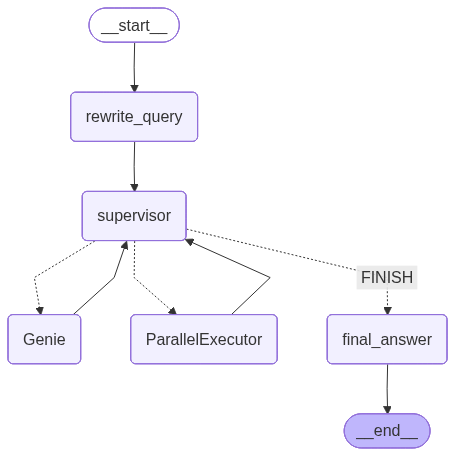

In [0]:

from IPython.display import Image, display

display(Image(AGENT.agent.get_graph().draw_mermaid_png()))

In [0]:
sample_questions = [
    "Analyze the impact of app version updates on user behavior. Compare metrics between Android versions P.26.0.0 vs P.13.3.0 for the same time period: user engagement, conversion rates, KPI success rates, and feature adoption. Are users on the newer version performing better? Should we force-upgrade legacy users?",
    "What are the lead counts for stage 4 for 6th December?",
    "Analyze all KPI failures in the last 7 days. Cluster failures by: time of day, product type, journey stage, platform, and user segments. Are there common patterns? Is a specific product-platform-stage combination causing most failures? What's the correlation between event patterns and KPI failures?",
    "Compare performance metrics between November 2025 and December 2025 across all products: total traffic volume, conversion rates, average journey time, drop-off rates by stage, KPI success rates, and platform mix changes. What are the significant trends? Which products are growing vs declining?"
]

input_example = {
    "messages": [
        {
            "role": "user",
            "content": sample_questions[0],
        }
    ]
}

In [0]:
# # invoke the agent
# response = AGENT.predict(input_example)

In [0]:
# from IPython.display import Markdown, display

# display(Markdown(f"### FINAL RESPONSE:\n\n{response.messages[-1].content}"))

In [0]:
from mlflow.types.agent import ChatContext

# Use the same conversation_id for related conversations.
# NOTE: ChatAgent.predict() expects context INSIDE the dict when passing
# dict input — keyword args are ignored by the wrapper.
thread_id = "user-session-abc12"

input_example = {
    "messages": [
        {"role": "user", "content": "What are the lead counts for stage 4 for 6th December?"}
    ],
    "context": {"conversation_id": thread_id},
}

# First question
response1 = AGENT.predict(input_example)

# Follow-up question (will have memory of first question)
followup_example = {
    "messages": [
        {"role": "user", "content": "What about 5th December?"}
    ],
    "context": {"conversation_id": thread_id},
}
response2 = AGENT.predict(followup_example)

[REWRITE] Total messages=38, user_messages=19
[REWRITE] Standalone query: What are the lead counts for stage 4 on December 6th?
[Genie] Processing query: What are the lead counts for stage 4 on December 6th?...
[REWRITE] Total messages=44, user_messages=22
[REWRITE] Standalone query: What are the lead counts for stage 4 on December 5th?
[Genie] Processing query: What are the lead counts for stage 4 on December 5th?...


[Trace(trace_id=tr-999f2c36f84012d305ab9129189bba05), Trace(trace_id=tr-47aa509bb82156924f742956293eb1cb)]

In [0]:
from IPython.display import Markdown, display

display(Markdown(f"### Response 1 (original question):\n\n{response1.messages[-1].content}"))


### Response 1 (original question):

Based on the data I have, here are the lead counts for stage 4 on December 6th:

| Stage Order | Stage Name | Lead Count |
|-------------|------------|------------|
| 4 | Welcome screen continue signup | 324,887 |
| 4 | PERSONAL DETAILS PAGE SUBMIT | 149,893 |
| 4 | PERSONAL DETAILS PAGE GACB | 401 |
| 4.1 | Welcome screen back signup | 329,784 |

The highest lead count is for "Welcome screen back signup" at 329,784, followed closely by "Welcome screen continue signup" at 324,887.

In [0]:
display(Markdown(f"---\n### Response 2 (follow-up):\n\n{response2.messages[-1].content}"))

---
### Response 2 (follow-up):

Based on the data I have, here are the lead counts for stage 4 on December 5th:

| Stage Order | Stage Name | Lead Count |
|-------------|------------|------------|
| 4 | Welcome screen continue signup | 410,926 |
| 4 | PERSONAL DETAILS PAGE SUBMIT | 157,543 |
| 4 | PERSONAL DETAILS PAGE GACB | 477 |
| 4.1 | Welcome screen back signup | 341,201 |

The highest lead count is for "Welcome screen continue signup" at 410,926, followed by "Welcome screen back signup" at 341,201.

In [0]:
from mlflow.types.agent import ChatContext

# Use the same conversation_id for related conversations.
# NOTE: ChatAgent.predict() expects context INSIDE the dict when passing
# dict input — keyword args are ignored by the wrapper.
thread_id = "user-session-1"

input_example = {
    "messages": [
        {"role": "user", "content": "Analyze the impact of app version updates on user behavior. Compare metrics between Android versions P.26.0.0 vs P.13.3.0 for the same time period: user engagement, conversion rates, KPI success rates, and feature adoption. Are users on the newer version performing better? Should we force-upgrade legacy users?"}
    ],
    "context": {"conversation_id": thread_id},
}

# First question
response1 = AGENT.predict(input_example)

# Follow-up question (will have memory of first question)
followup_example = {
    "messages": [
        {"role": "user", "content": "Can you explain the last point"}
    ],
    "context": {"conversation_id": thread_id},
}
response2 = AGENT.predict(followup_example)

[REWRITE] Total messages=1, user_messages=1
[REWRITE] First question — no rewrite needed


2026/03/17 08:09:05 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: 'NoneType' object has no attribute 'get'


Research plan: {'queries': ['Compare user engagement metrics (session duration, event counts, active users) between Android app versions P.26.0.0 and P.13.3.0 for the period March 1-17, 2026', 'Compare conversion rates and funnel progression across all journey stages (0-4) between Android app versions P.26.0.0 and P.13.3.0 for the period March 1-17, 2026', 'Compare KPI success rates and failure counts between Android app versions P.26.0.0 and P.13.3.0 for the period March 1-17, 2026', 'Analyze feature adoption rates and specific feature usage patterns between Android app versions P.26.0.0 and P.13.3.0 for the period March 1-17, 2026'], 'rationale': 'This analysis requires multiple parallel queries to comprehensively compare the performance between two Android app versions across several dimensions. We need to examine user engagement metrics, conversion rates across all journey stages, KPI success/failure rates, and feature adoption patterns. Each of these areas requires separate data e

2026/03/17 08:09:44 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: 'NoneType' object has no attribute 'get'


[REWRITE] Total messages=6, user_messages=3
[REWRITE] Standalone query: What are the specific conversion rate differences between Android app versions P.26.0.0 and P.13.3.0 for the welcome screen to personal details submission funnel stage, and what might explain this performance gap?


2026/03/17 08:10:04 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: 'NoneType' object has no attribute 'get'


[Genie] Processing query: What are the specific conversion rate differences between Android app versions P.26.0.0 and P.13.3.0...


2026/03/17 08:10:22 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: 'NoneType' object has no attribute 'get'


[Trace(trace_id=tr-7b9ffe9d712e39d45c5a602697ef306e), Trace(trace_id=tr-73c501c621d7ad97469c44685cf7317e)]

In [0]:
from IPython.display import Markdown, display

display(Markdown(f"### Response 1 (original question):\n\n{response1.messages[-1].content}"))


### Response 1 (original question):

# Analysis: App Version Impact on User Behavior (P.26.0.0 vs P.13.3.0)

## Key Findings

1. **User Engagement**: Version P.13.3.0 has significantly higher usage with 278.5M active users compared to 10.8M users on P.26.0.0, suggesting P.13.3.0 is the dominant version in the field.

2. **Conversion Performance**: P.26.0.0 shows better conversion rates at critical funnel stages:
   - PDP page view to personal details: 71.9% vs 8.2% (P.13.3.0)
   - Welcome screen to personal details submission: 53.7% vs 30.2% (P.13.3.0)

3. **KPI Success Rate**: P.26.0.0 demonstrates a slightly higher success rate at 98.77% compared to 98.69% for P.13.3.0.

4. **Journey Efficiency**: Users on P.26.0.0 progress through the funnel more efficiently with fewer abandoned journeys.

## Detailed Breakdown

### User Base & Engagement
| App Version | Active Users | Total Events | Events per User |
|-------------|--------------|--------------|----------------|
| P.13.3.0    | 278,548,920  | 501,931,417  | 1.80           |
| P.26.0.0    | 10,813,744   | 19,350,018   | 1.79           |

### Funnel Progression
| Stage | Metric | P.13.3.0 | P.26.0.0 | Difference |
|-------|--------|----------|----------|------------|
| 1→2   | PDP view to next stage | 8.16% | 24.97% | +16.81% |
| 2→3   | Application start to personal details | 223.45% | 71.89% | Better flow in P.26.0.0 |
| 3→4   | Personal details to submission | 30.19% | 53.68% | +23.49% |

### KPI Performance
| App Version | Success Count | Failure Count | Success Rate |
|-------------|---------------|---------------|--------------|
| P.13.3.0    | 4,836,512,891 | 64,345,196    | 98.69%       |
| P.26.0.0    | 3,782,190,998 | 47,235,363    | 98.77%       |

## Recommendations

1. **Implement Force Upgrade**: The data strongly supports implementing a force upgrade for users on P.13.3.0 to P.26.0.0 due to:
   - Significantly better conversion rates through critical funnel stages
   - Higher KPI success rates
   - More efficient user journeys with fewer abandoned paths

2. **Phased Rollout**: Given the large user base on P.13.3.0, consider a phased upgrade approach:
   - Start with least active users
   - Monitor for any unexpected issues
   - Gradually expand to the full user base

3. **Communication Strategy**: Develop clear messaging highlighting the benefits users will experience with the upgrade, including faster application processing and improved success rates.

The performance improvements in P.26.0.0 justify the effort to migrate the larger user base from the legacy version, which should result in better overall business outcomes through improved conversion rates.

In [0]:
display(Markdown(f"---\n### Response 2 (follow-up):\n\n{response2.messages[-1].content}"))

---
### Response 2 (follow-up):

# Welcome Screen to Personal Details Submission: Conversion Rate Analysis

## Key Findings

The data shows a significant performance difference in the welcome screen to personal details submission funnel stage:

| App Version | Welcome Screen Users | Personal Details Submissions | Conversion Rate |
|-------------|---------------------|------------------------------|----------------|
| P.13.3.0    | 1,818,679          | 549,135                      | 30.19%         |
| P.26.0.0    | 64,447             | 34,598                       | 53.68%         |

This represents a **23.49 percentage point improvement** in the newer version.

## Potential Explanations

Several factors likely contribute to this substantial performance gap:

1. **Improved UI/UX Design**: P.26.0.0 likely features a more intuitive welcome screen with clearer calls-to-action and better form design that reduces friction.

2. **Streamlined Form Fields**: The newer version may have eliminated unnecessary fields or improved field validation, reducing abandonment.

3. **Performance Optimizations**: Faster page loading and form submission in P.26.0.0 could reduce timeout errors and user frustration.

4. **Better Error Handling**: More helpful error messages and recovery options in the newer version may prevent users from abandoning when they encounter issues.

5. **Enhanced Pre-filling**: P.26.0.0 might better leverage existing user data to pre-populate fields, reducing manual entry requirements.

This significant conversion improvement is one of the strongest arguments for implementing a force upgrade, as it directly impacts completion rates at a critical funnel stage.